# Age labels 


In [ ]:
# readed from AgeVoxCeleb
#Loads AgeVoxCeleb recordings from `final_dataframe_extended.csv`.
#Builds a speaker pool with age range ≥1 year (needed for same-speaker LRP pairs).
#Results are cached to `data/pool_lrp.pkl` so subsequent runs skip the slow expansion step.

In [1]:
import sys
sys.path.insert(0, '/path/to/project')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

print('Imports OK')

Imports OK


In [2]:
import sys
sys.path.insert(0, "/path/to/project/scripts")
from extract_n import extract_n, extract_n_sec


## Paths

In [50]:
AGEVOXCELEB    = Path('/datasets/age-vox-celeb/voxceleb_enrichment_age_gender')
ENRICHMENT_CSV = AGEVOXCELEB / 'dataset/final_dataframe_extended.csv'
TRAIN_TXT      = AGEVOXCELEB / 'dataset/age-train.txt'
TEST_TXT       = AGEVOXCELEB / 'dataset/age-test.txt'
VOXCELEB2_ROOT = '/path/to/VOXCELEB2_ROOT'
POOL_CACHE     = Path('/path/to/project/data/pool.pkl')

## Build recording pool (with pickle cache)

In [51]:
train_df = pd.read_csv(TRAIN_TXT)
test_df  = pd.read_csv(TEST_TXT)

print(f'Train: {len(train_df):,} videos, {train_df.VoxCeleb_ID.nunique():,} speakers')
print(f'Test:  {len(test_df):,} videos,  {test_df.VoxCeleb_ID.nunique():,} speakers')
print(f'Age range train: {train_df.speaker_age.min():.0f}–{train_df.speaker_age.max():.0f} yr')
print(f'Age range test:  {test_df.speaker_age.min():.0f}–{test_df.speaker_age.max():.0f} yr')

Train: 1,690 videos, 1,690 speakers
Test:  1,127 videos,  1,127 speakers
Age range train: 12–90 yr
Age range test:  12–83 yr


In [52]:
set(test_df.VoxCeleb_ID.isin(train_df.VoxCeleb_ID))

{False}

In [53]:
test_df.shape[0] + train_df.shape[0]

2817

In [54]:
from paperutils.sv2 import get_all_paths

if POOL_CACHE.exists():
    data = pd.read_pickle(POOL_CACHE)
    print(f'Loaded cache: {POOL_CACHE}  ({len(data):,} rows)')
else:
    print('No cache — building from scratch (a few minutes)...')
    raw  = pd.read_csv(ENRICHMENT_CSV, low_memory=False)
    data = get_all_paths(raw, VOXCELEB2_ROOT)
    data = data[['VoxCeleb_ID','video_id','gender', 'speaker_age', 'recording_path']]
    POOL_CACHE.parent.mkdir(parents=True, exist_ok=True)
    data.to_pickle(POOL_CACHE)
    print(f'Saved cache: {POOL_CACHE}')

print(f'Speakers: {data.VoxCeleb_ID.nunique():,}  recordings: {len(data):,}')

Loaded cache: /home/dgutowska/wavlmecapa/data/pool.pkl  (1,120,591 rows)
Speakers: 6,112  recordings: 1,120,591


In [55]:
data=data.dropna(subset=["speaker_age"])

In [56]:
one_interview_per_speaker=data.drop_duplicates(subset=["video_id"])

In [57]:
one_interview_per_speaker.to_csv("one_interview_per_speaker.csv")

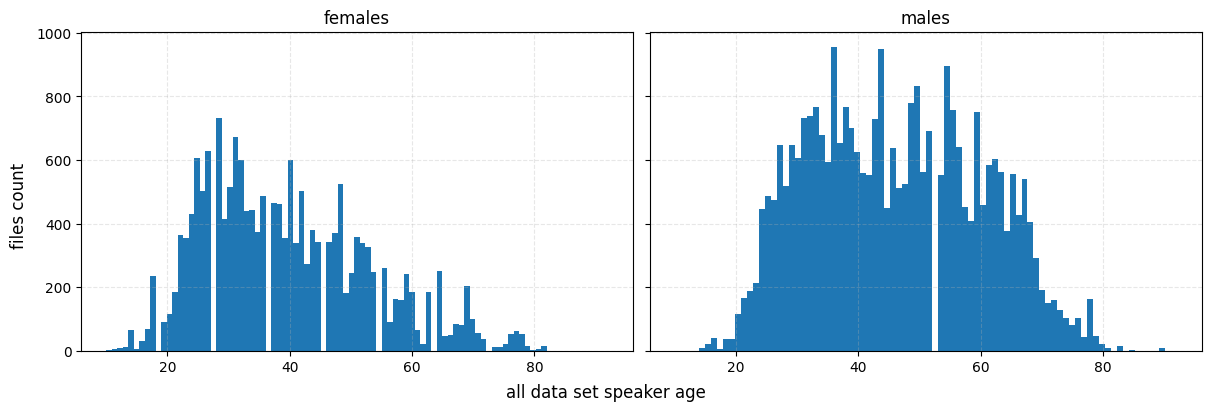

In [58]:

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True,
                       constrained_layout=True)

data[data.gender == "female"].speaker_age.hist(bins=80, ax=axes[0])
axes[0].set_title('females')

data[data.gender == "male"].speaker_age.hist(bins=80, ax=axes[1])
axes[1].set_title('males')
for ax in axes:
  ax.grid(True, alpha=0.3, linestyle='--')

fig.supxlabel('all data set speaker age')        # wspólna oś X pod oboma subplotami
fig.supylabel('files count')              # wspólna oś Y po lewej

plt.show()


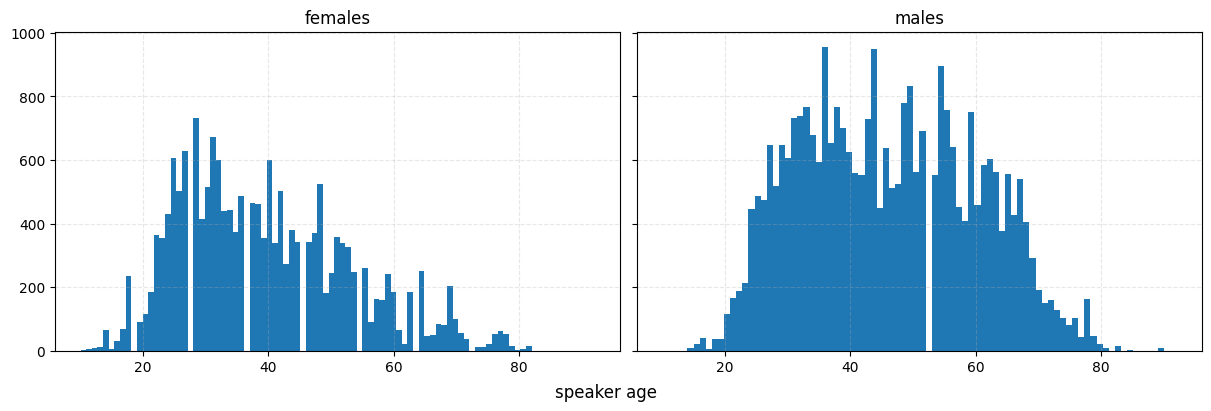

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True,
                       constrained_layout=True)

# górny wiersz — train
data[data.gender == "female"].speaker_age.hist(bins=80, ax=axes[0])
data[data.gender == "male"].speaker_age.hist(bins=80, ax=axes[1])

axes[0].set_title('females')
axes[1].set_title('males')

# siatka na wszystkich osiach
for ax in axes:
  ax.grid(True, alpha=0.3, linestyle='--')

fig.supxlabel('speaker age')

plt.show()



In [65]:
one_interview_per_speaker=data.drop_duplicates(subset=["video_id"])

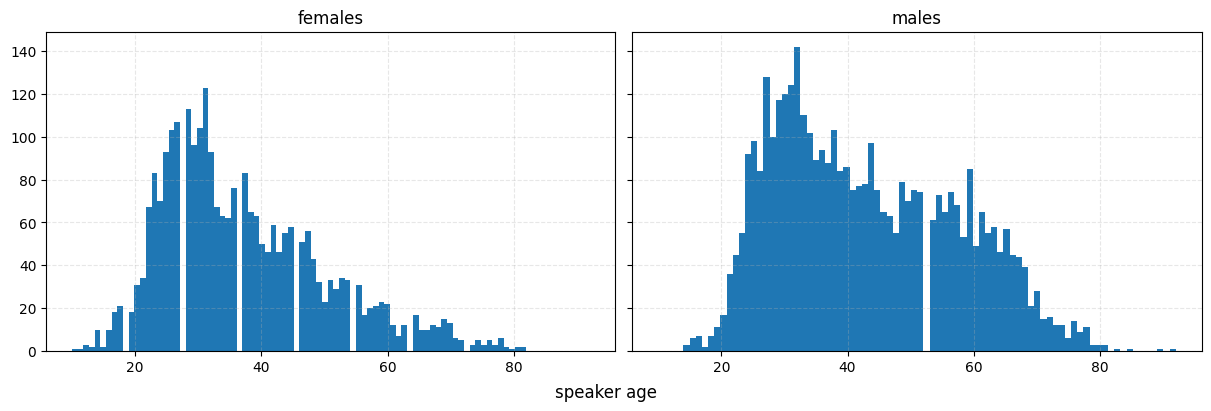

In [66]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True,
                       constrained_layout=True)

one_interview_per_speaker[one_interview_per_speaker.gender == "female"].speaker_age.hist(bins=80, ax=axes[0])
one_interview_per_speaker[one_interview_per_speaker.gender == "male"].speaker_age.hist(bins=80, ax=axes[1])

axes[0].set_title('females')
axes[1].set_title('males')

# siatka na wszystkich osiach
for ax in axes.flat:
  ax.grid(True, alpha=0.3, linestyle='--')

fig.supxlabel('speaker age')

plt.show()



# select recordings at least 5 years apart

In [67]:
age_range = data.groupby('VoxCeleb_ID')['speaker_age'].agg(lambda x: x.max() - x.min())
age_range=age_range.to_frame(name="wartosc")
age_range = age_range.reset_index()
age_range.columns = ["VoxCeleb_ID", "speaker_age"]

In [68]:
selected_speakers_id = age_range[age_range.speaker_age>=5].VoxCeleb_ID.values

In [69]:
data = data[data.VoxCeleb_ID.isin(selected_speakers_id)]

In [70]:
data.shape

(10932, 5)

In [71]:
data.drop_duplicates(subset=["VoxCeleb_ID"]).shape

(334, 5)

In [72]:
# only 334 speakers have recording with at least 5 years apart

## data description

In [77]:
data[data.gender=="male"].shape[0], data[data.gender=="female"].shape[0] 

(7058, 3874)

In [78]:
age_range_map = age_range.set_index("VoxCeleb_ID")["speaker_age"].to_dict()

In [79]:
data["age_range"]=data.VoxCeleb_ID.map(age_range_map)

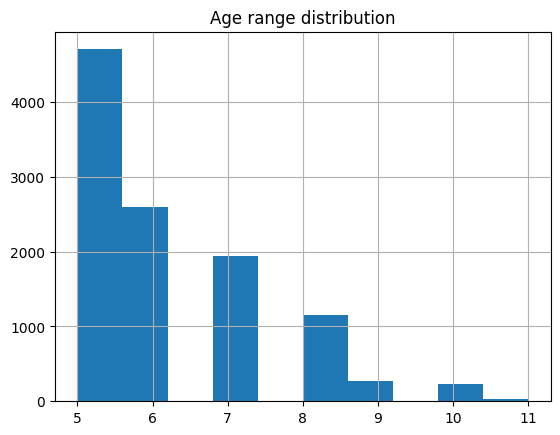

In [80]:
data["age_range"].hist()
plt.title("Age range distribution")
plt.show()


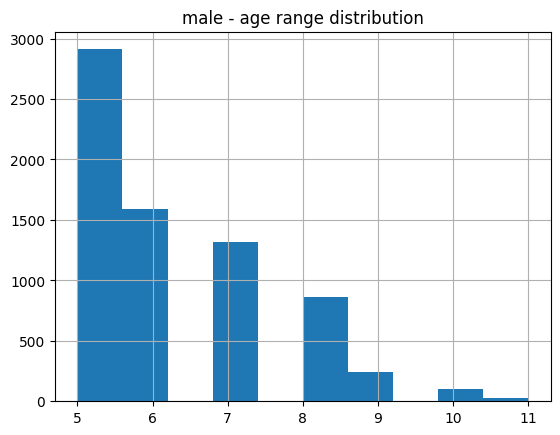

In [81]:
data[data.gender=="male"]["age_range"].hist()
plt.title("male - age range distribution")
plt.show()


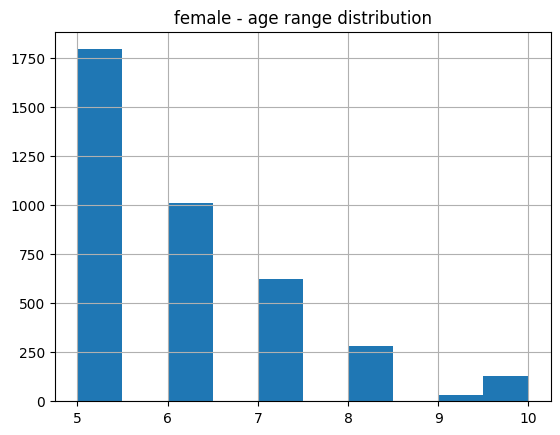

In [82]:
data[data.gender=="female"]["age_range"].hist()
plt.title("female - age range distribution")
plt.show()


In [83]:
data.shape

(10932, 6)

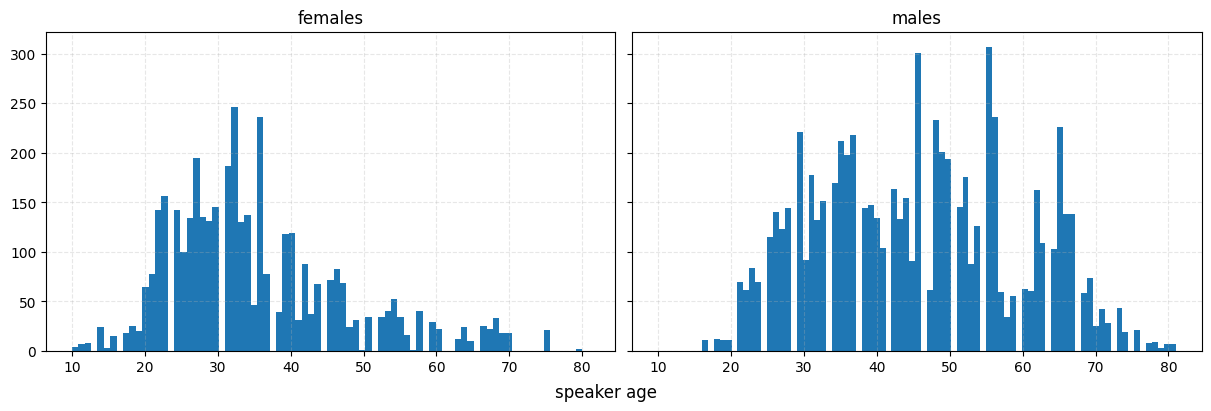

In [84]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True,
                       constrained_layout=True)

data[data.gender == "female"].speaker_age.hist(bins=80, ax=axes[0])
data[data.gender == "male"].speaker_age.hist(bins=80, ax=axes[1])

axes[0].set_title('females')
axes[1].set_title('males')

# siatka na wszystkich osiach
for ax in axes.flat:
  ax.grid(True, alpha=0.3, linestyle='--')

fig.supxlabel('speaker age')

plt.show()



In [36]:
data.to_pickle("selected_speakers_id_by_age_range.pkl")